# Análisis del barrido OFAT — sweep v2

Compara resistencia cognitiva en 1 000 runs (2 topologías × 20 celdas OFAT × 50 réplicas MC).

**Factores barridos:** γ, estrategia semillas, fanout, k\_seeds, prob. reenvío, fracción susceptibles, carga emocional.

**Fuentes:**
- `sweep_summary.csv` — 1 fila/run, todas las métricas escalares.
- `simulation_adoptions.csv` por run — curva de adopción temporal (sección 4.4).

**Estructura de celdas:**
- 4.1 Curvas marginales por factor (resiliencia media ± std)
- 4.2 Boxplot de tasa de ataque por celda
- 4.3 Vulnerabilidad estructural: hubs vs random
- 4.4 Curva de adopción media ± banda temporal
- 4.5 Velocidad: t50 y t_peak
- 4.6 Heatmap resumen factor × nivel
- Drill-down: análisis por-nodo de un run específico

In [1]:
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Edita aquí para apuntar a tu run de sweep ----------------------------
SWEEP_ROOT = Path("../../data/results/sweep")
STEPS_TOTAL = 45  # DAYS × STEPS_PER_DAY, debe coincidir con sweep.py
# --------------------------------------------------------------------------

SUMMARY_PATH = SWEEP_ROOT / "sweep_summary.csv"

IMG_DIR = Path("../../Burocracia/Memoria/images")

COLORS = {"scale_free": "#e05c5c", "small_world": "#4a90d9"}
ALPHA_BAND = 0.18

FACTORS_ORDERED = [
    "gamma",
    "seed_strategy",
    "seed_fanout",
    "k_seeds",
    "forward_probability",
    "susceptible_fraction",
    "emotional_load",
]
FACTOR_LABELS = {
    "gamma":                "γ (persuasión)",
    "seed_strategy":        "Estrategia semillas",
    "seed_fanout":          "Fanout semillas",
    "k_seeds":              "Fracción semillas k",
    "forward_probability":  "Prob. reenvío",
    "susceptible_fraction": "Frac. susceptibles",
    "emotional_load":       "Carga emocional",
}

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Carga de datos

In [2]:
df = pd.read_csv(SUMMARY_PATH)

for col in ["tasa_ataque", "resiliencia", "t50", "t_peak", "mean_Ri", "reach", "narrative_msgs"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["valor_str"] = df["valor"].astype(str)

print(f"Runs cargados: {len(df)}")
print(df.groupby(["topology", "factor"])["seed"].count().rename("n_runs").to_string())
df.head()

Runs cargados: 2000
topology     factor              
scale_free   emotional_load          150
             forward_probability     150
             gamma                   150
             k_seeds                 150
             seed_fanout             150
             seed_strategy           100
             susceptible_fraction    150
small_world  emotional_load          150
             forward_probability     150
             gamma                   150
             k_seeds                 150
             seed_fanout             150
             seed_strategy           100
             susceptible_fraction    150


,topology,factor,valor,k_abs,seed,N,seeds,conversiones,tasa_ataque,resiliencia,entropia,t50,reach,narrative_msgs,mean_Ri,peak_new,t_peak,valor_str
0,scale_free,gamma,0.25,NaN,1000,10000,50,964,0.0969,0.9031,0.4590,22,6653,27118,0.4997,74,0,0.25
1,scale_free,gamma,0.25,NaN,1002,10000,50,980,0.0985,0.9015,0.4642,23,6715,30343,0.4989,63,0,0.25
2,scale_free,gamma,0.25,NaN,1001,10000,50,900,0.0905,0.9095,0.4380,23,6696,24793,0.4970,48,43,0.25
3,scale_free,gamma,0.25,NaN,1004,10000,50,976,0.0981,0.9019,0.4629,26,6478,28733,0.4956,74,35,0.25
4,scale_free,gamma,0.25,NaN,1003,10000,50,863,0.0867,0.9133,0.4255,28,6858,30772,0.4980,55,0,0.25


## 4.1 Curvas marginales por factor

Resiliencia media ± 1 std sobre las 10 réplicas MC, por nivel y topología.
La banda sombreada muestra la varianza inter-réplica. Responde: *¿cuánto mueve
cada palanca la resiliencia, y con cuánta dispersión?*

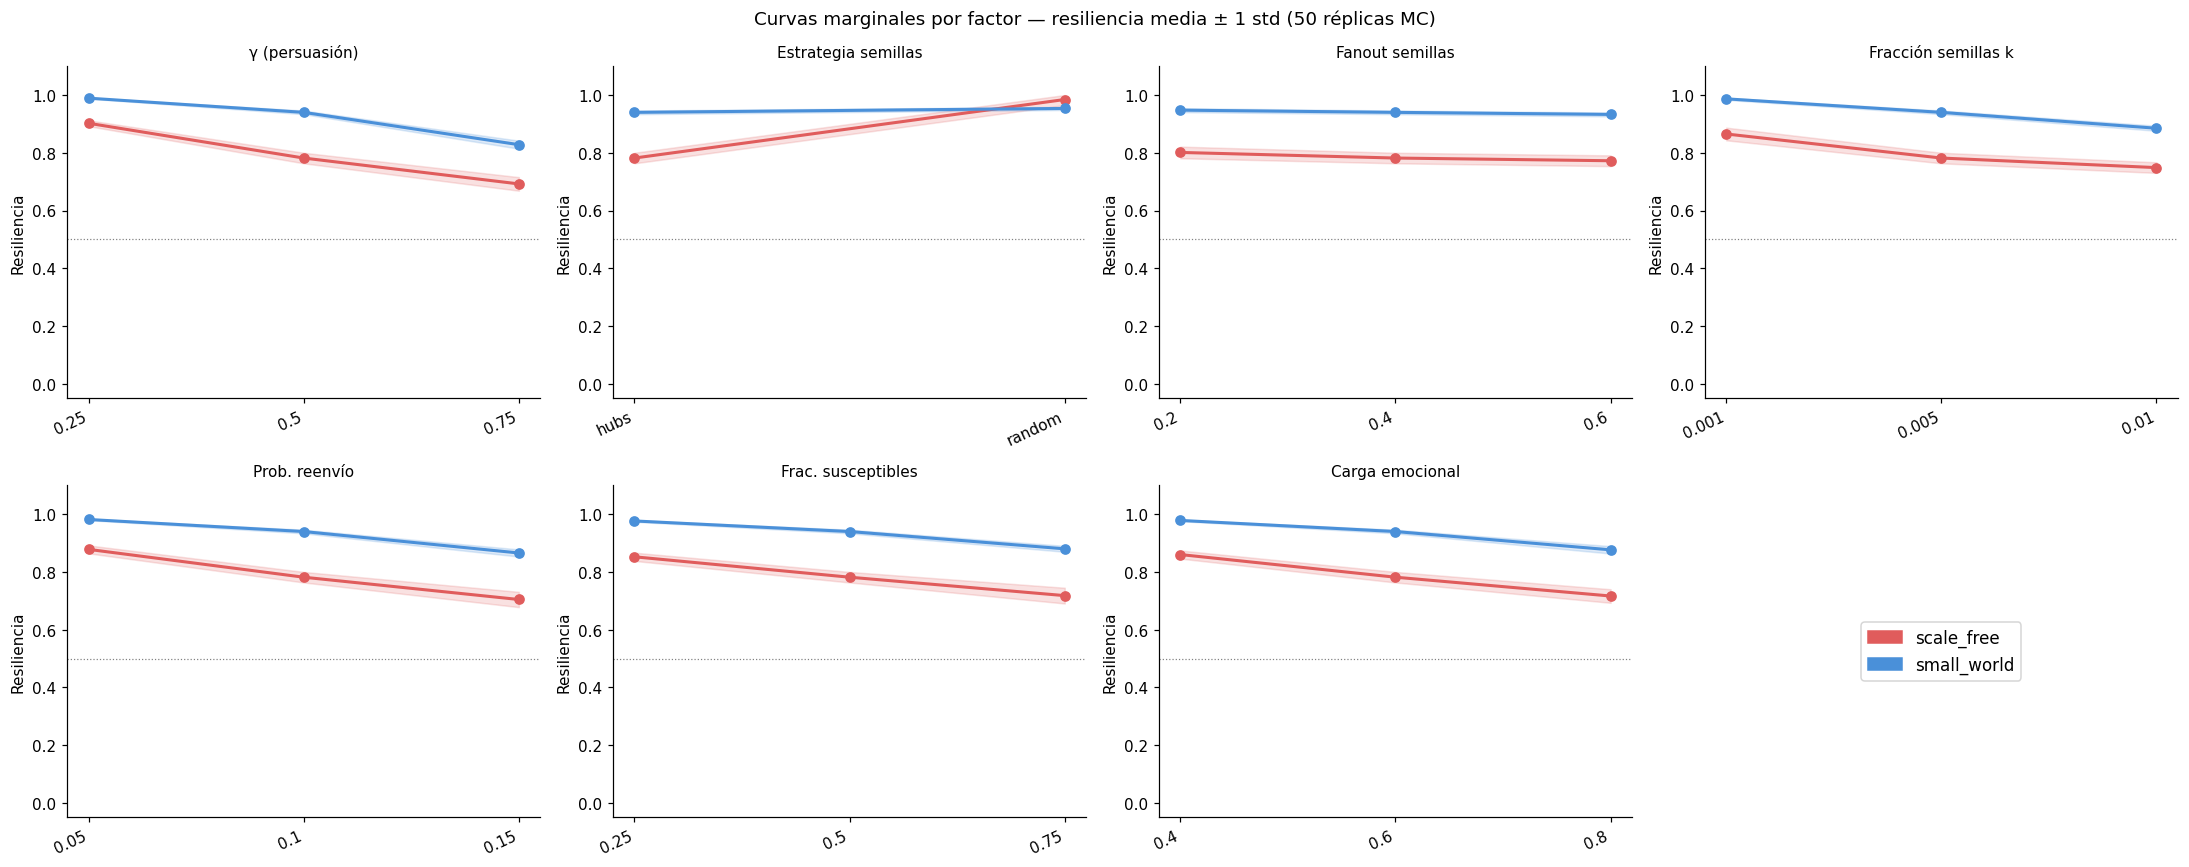

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes_flat = axes.flatten()

for i, factor in enumerate(FACTORS_ORDERED):
    ax = axes_flat[i]
    sub = df[df["factor"] == factor].copy()
    valores = sorted(sub["valor_str"].unique())

    for topo, color in COLORS.items():
        grp = sub[sub["topology"] == topo].groupby("valor_str")["resiliencia"]
        means = grp.mean().reindex(valores)
        stds  = grp.std().reindex(valores)
        x = range(len(valores))
        ax.plot(x, means.values, "o-", color=color, label=topo, lw=2, ms=6)
        ax.fill_between(
            x,
            (means - stds).clip(0).values,
            (means + stds).clip(upper=1).values,
            color=color,
            alpha=ALPHA_BAND,
        )

    ax.set_xticks(range(len(valores)))
    ax.set_xticklabels(valores, rotation=25, ha="right")
    ax.set_title(FACTOR_LABELS[factor], fontsize=10)
    ax.set_ylabel("Resiliencia")
    ax.set_ylim(-0.05, 1.1)
    ax.axhline(0.5, ls=":", lw=0.8, color="grey")

handles = [mpatches.Patch(color=c, label=t) for t, c in COLORS.items()]
axes_flat[7].legend(handles=handles, loc="center", fontsize=11)
axes_flat[7].axis("off")

fig.suptitle("Curvas marginales por factor — resiliencia media ± 1 std (50 réplicas MC)", fontsize=12)
plt.tight_layout()
fig.savefig(IMG_DIR / "sweep_marginal_resiliencia.png", dpi=200, bbox_inches="tight")
plt.show()

## 4.2 Boxplot de tasa de ataque por celda

Distribución completa de las 50 réplicas por nivel y topología. Detecta asimetría,
colas y bimodalidad (cascada vs. no-cascada) que la media ± std no captura.

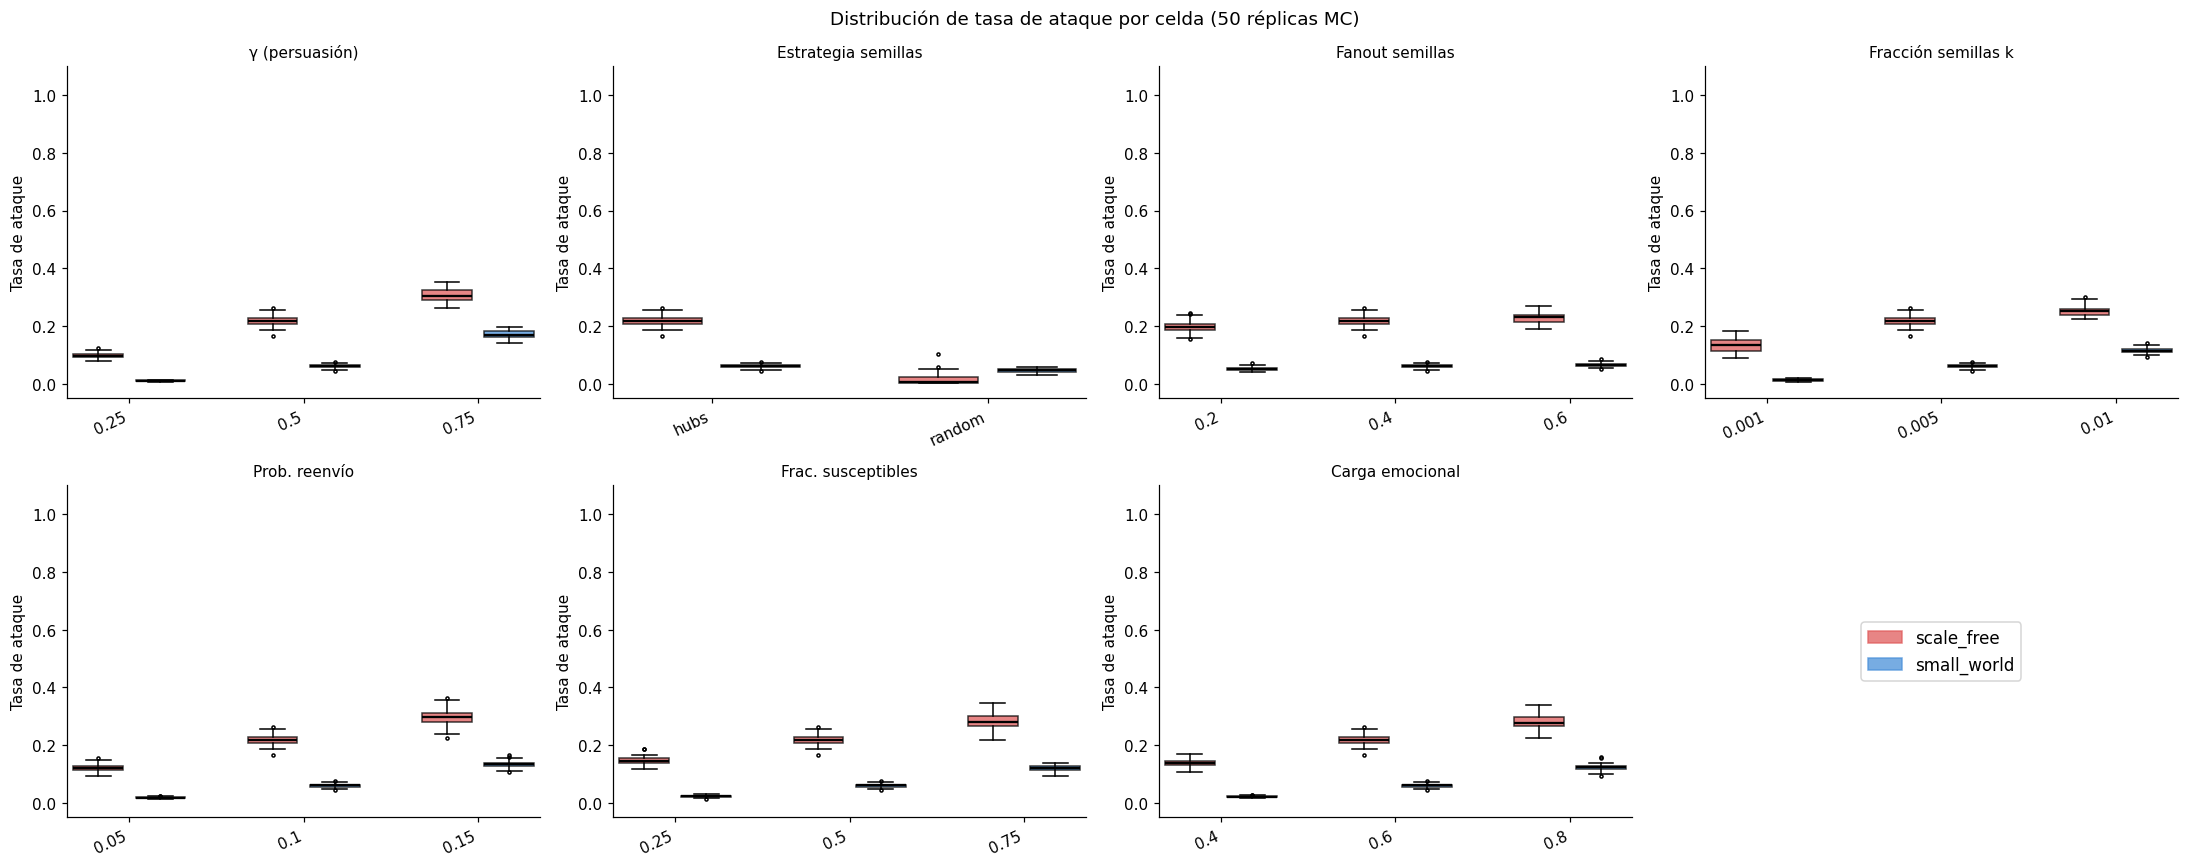

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes_flat = axes.flatten()

for i, factor in enumerate(FACTORS_ORDERED):
    ax = axes_flat[i]
    sub = df[df["factor"] == factor].copy()
    valores = sorted(sub["valor_str"].unique())
    n = len(valores)

    gap = 2.8
    pos_sf = [j * gap for j in range(n)]
    pos_sw = [j * gap + 1.0 for j in range(n)]

    def get_data(topo: str) -> list[list[float]]:
        return [
            sub[(sub["topology"] == topo) & (sub["valor_str"] == v)]["tasa_ataque"]
            .dropna().tolist()
            for v in valores
        ]

    ax.boxplot(
        get_data("scale_free"), positions=pos_sf, widths=0.8, patch_artist=True,
        boxprops=dict(facecolor=COLORS["scale_free"], alpha=0.75),
        medianprops=dict(color="black", lw=1.5), whiskerprops=dict(lw=1),
        capprops=dict(lw=1), flierprops=dict(marker=".", ms=4),
    )
    ax.boxplot(
        get_data("small_world"), positions=pos_sw, widths=0.8, patch_artist=True,
        boxprops=dict(facecolor=COLORS["small_world"], alpha=0.75),
        medianprops=dict(color="black", lw=1.5), whiskerprops=dict(lw=1),
        capprops=dict(lw=1), flierprops=dict(marker=".", ms=4),
    )

    ax.set_xticks([j * gap + 0.5 for j in range(n)])
    ax.set_xticklabels(valores, rotation=25, ha="right")
    ax.set_title(FACTOR_LABELS[factor], fontsize=10)
    ax.set_ylabel("Tasa de ataque")
    ax.set_ylim(-0.05, 1.1)

handles = [mpatches.Patch(color=c, alpha=0.75, label=t) for t, c in COLORS.items()]
axes_flat[7].legend(handles=handles, loc="center", fontsize=11)
axes_flat[7].axis("off")

fig.suptitle("Distribución de tasa de ataque por celda (50 réplicas MC)", fontsize=12)
plt.tight_layout()
plt.show()

## 4.3 Vulnerabilidad estructural: hubs vs random

La brecha entre estrategias mide la **vulnerabilidad por topología**:
debería ser grande en scale-free (hubs concentran audiencia) y pequeña en
small-world (grado casi homogéneo, sin hubs reales).

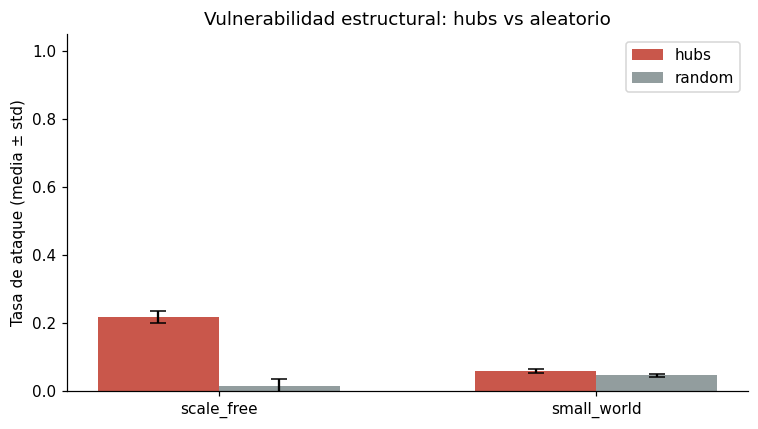

valor         hubs  random  brecha hubs−random
topology                                      
scale_free   0.218   0.015               0.203
small_world  0.060   0.046               0.014


In [5]:
sub = df[df["factor"] == "seed_strategy"].copy()
stats = (
    sub.groupby(["topology", "valor"])["tasa_ataque"]
    .agg(["mean", "std"])
    .reset_index()
)

topos = list(COLORS.keys())
strategies = ["hubs", "random"]
x = np.arange(len(topos))
width = 0.32

fig, ax = plt.subplots(figsize=(7, 4))
palette = ["#c0392b", "#7f8c8d"]

for j, strat in enumerate(strategies):
    row = stats[stats["valor"] == strat].set_index("topology").reindex(topos)
    ax.bar(
        x + j * width, row["mean"], width,
        yerr=row["std"], label=strat,
        color=palette[j], alpha=0.85, capsize=5,
    )

ax.set_xticks(x + width / 2)
ax.set_xticklabels(topos)
ax.set_ylabel("Tasa de ataque (media ± std)")
ax.set_title("Vulnerabilidad estructural: hubs vs aleatorio")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
fig.savefig(IMG_DIR / "sweep_hubs_vs_random.png", dpi=200, bbox_inches="tight")
plt.show()

pivot = stats.pivot(index="topology", columns="valor", values="mean")
pivot["brecha hubs−random"] = pivot.get("hubs", np.nan) - pivot.get("random", np.nan)
print(pivot.round(3).to_string())

## 4.4 Curva de adopción media ± banda temporal

Creyentes acumulados por timestep, promediados sobre las 10 réplicas MC, con
banda ±std. Muestra la **varianza temporal** (no solo la métrica final).

Ajusta `FACTOR_TEMPORAL` para explorar distintos factores.

/tmp/ipykernel_195012/3573621958.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(valores))


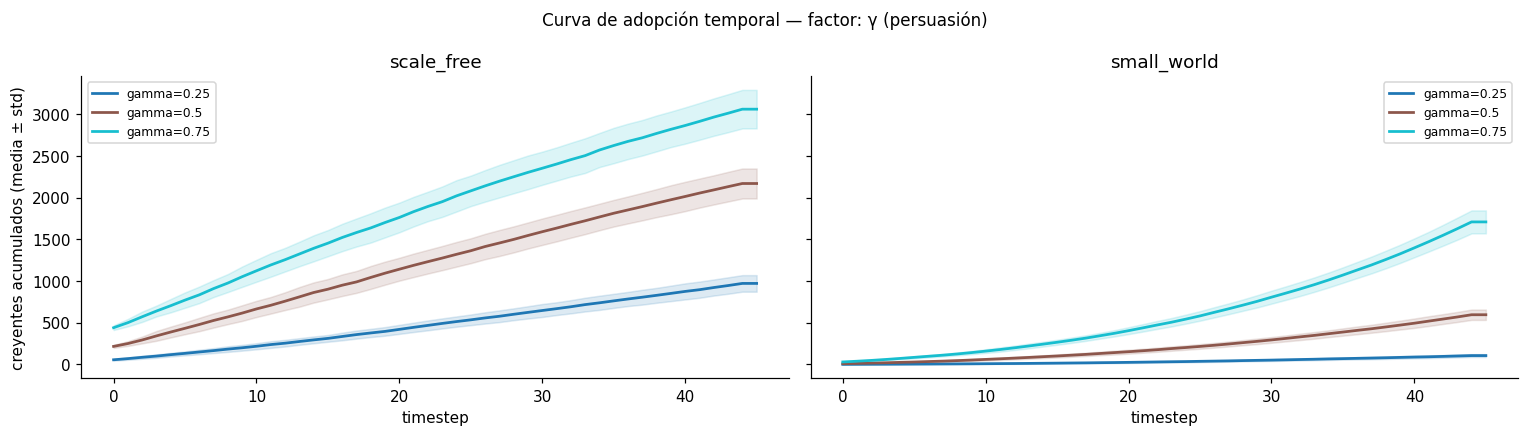

In [6]:
FACTOR_TEMPORAL = "gamma"  # edita para explorar: gamma, emotional_load, susceptible_fraction…
BASE_SEED = 1000
N_REPLICAS = 50


def _load_cum_adoption(factor: str, valor: str, topo: str) -> np.ndarray:
    """Devuelve array (réplicas, STEPS_TOTAL+1) con adopciones acumuladas."""
    curves = []
    for r in range(N_REPLICAS):
        seed = BASE_SEED + r
        path = (
            SWEEP_ROOT / topo / factor
            / f"{factor}={valor}" / f"seed={seed}"
            / "sim" / "simulation_adoptions.csv"
        )
        if not path.exists():
            continue
        adp = pd.read_csv(path)
        by_t = adp.groupby("timestep").size()
        cum = by_t.cumsum().reindex(range(STEPS_TOTAL + 1), method="ffill").fillna(0)
        curves.append(cum.to_numpy())
    return np.array(curves) if curves else np.zeros((1, STEPS_TOTAL + 1))


sub_f = df[df["factor"] == FACTOR_TEMPORAL]
valores = sorted(sub_f["valor_str"].unique())
t_axis = np.arange(STEPS_TOTAL + 1)

cmap = plt.cm.get_cmap("tab10", len(valores))
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, (topo, topo_color) in zip(axes, COLORS.items()):
    for idx, valor in enumerate(valores):
        curves = _load_cum_adoption(FACTOR_TEMPORAL, valor, topo)
        mean_c = curves.mean(axis=0)
        std_c  = curves.std(axis=0)
        c = cmap(idx)
        ax.plot(t_axis, mean_c, lw=1.8, color=c, label=f"{FACTOR_TEMPORAL}={valor}")
        ax.fill_between(t_axis, (mean_c - std_c).clip(0), mean_c + std_c, color=c, alpha=0.15)
    ax.set_title(topo)
    ax.set_xlabel("timestep")
    ax.legend(fontsize=8)

axes[0].set_ylabel("creyentes acumulados (media ± std)")
fig.suptitle(
    f"Curva de adopción temporal — factor: {FACTOR_LABELS[FACTOR_TEMPORAL]}",
    fontsize=11,
)
plt.tight_layout()
fig.savefig(IMG_DIR / "sweep_temporal_gamma.png", dpi=200, bbox_inches="tight")
plt.show()

## 4.4.2 Curva de adopción temporal — fracción de susceptibles

Fija el factor en `susceptible_fraction` y muestra cómo la composición de la
población (qué fracción tiene umbral bajo) determina la velocidad y altura de
la cascada. Complementa la curva marginal escalar con la dinámica completa.

/tmp/ipykernel_195012/2261512331.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = plt.cm.get_cmap("Set1", len(valores_sf))


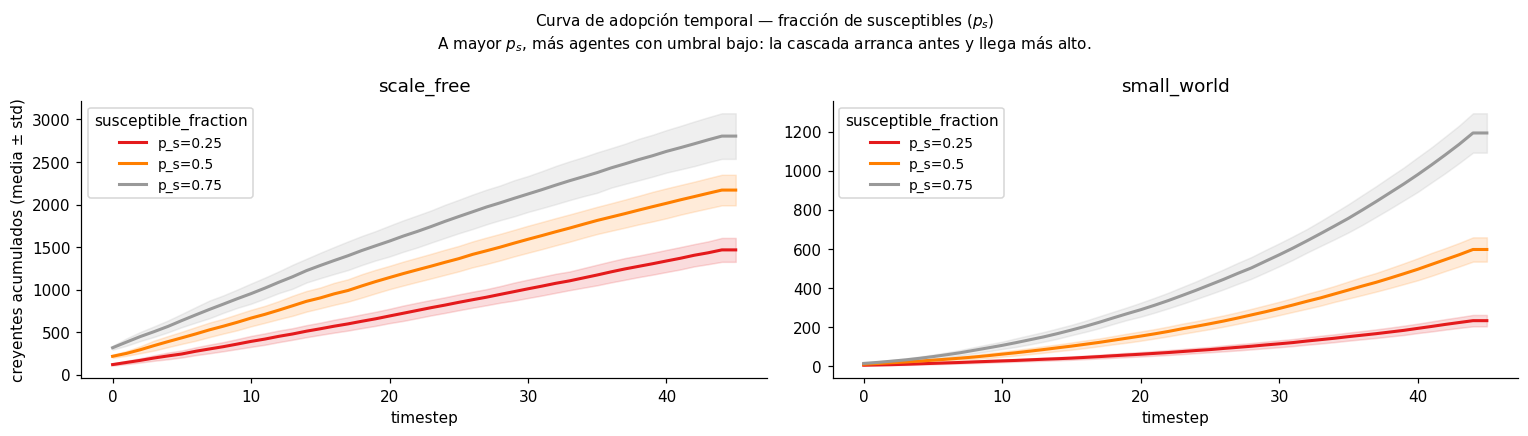

In [7]:
_FACTOR = "susceptible_fraction"
sub_sf = df[df["factor"] == _FACTOR]
valores_sf = sorted(sub_sf["valor_str"].unique())
t_axis = np.arange(STEPS_TOTAL + 1)

cmap2 = plt.cm.get_cmap("Set1", len(valores_sf))
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

for ax, (topo, _) in zip(axes, COLORS.items()):
    for idx, valor in enumerate(valores_sf):
        curves = _load_cum_adoption(_FACTOR, valor, topo)
        mean_c = curves.mean(axis=0)
        std_c  = curves.std(axis=0)
        c = cmap2(idx)
        ax.plot(t_axis, mean_c, lw=2, color=c, label=f"p_s={valor}")
        ax.fill_between(t_axis, (mean_c - std_c).clip(0), mean_c + std_c,
                        color=c, alpha=0.15)
    ax.set_title(topo)
    ax.set_xlabel("timestep")
    ax.legend(fontsize=9, title="susceptible_fraction")

axes[0].set_ylabel("creyentes acumulados (media ± std)")
fig.suptitle(
    "Curva de adopción temporal — fracción de susceptibles ($p_s$)\n"
    "A mayor $p_s$, más agentes con umbral bajo: la cascada arranca antes y llega más alto.",
    fontsize=10,
)
plt.tight_layout()
fig.savefig(IMG_DIR / "sweep_temporal_susceptible.png", dpi=200, bbox_inches="tight")
plt.show()

## 4.5 Velocidad: t50 y t_peak

Boxplot del paso de tiempo en que se alcanza el 50% de conversiones (t50) y el
pico de nuevas adopciones (t_peak), agrupado por factor y topología.
Complementa la magnitud (tasa de ataque) con la rapidez.

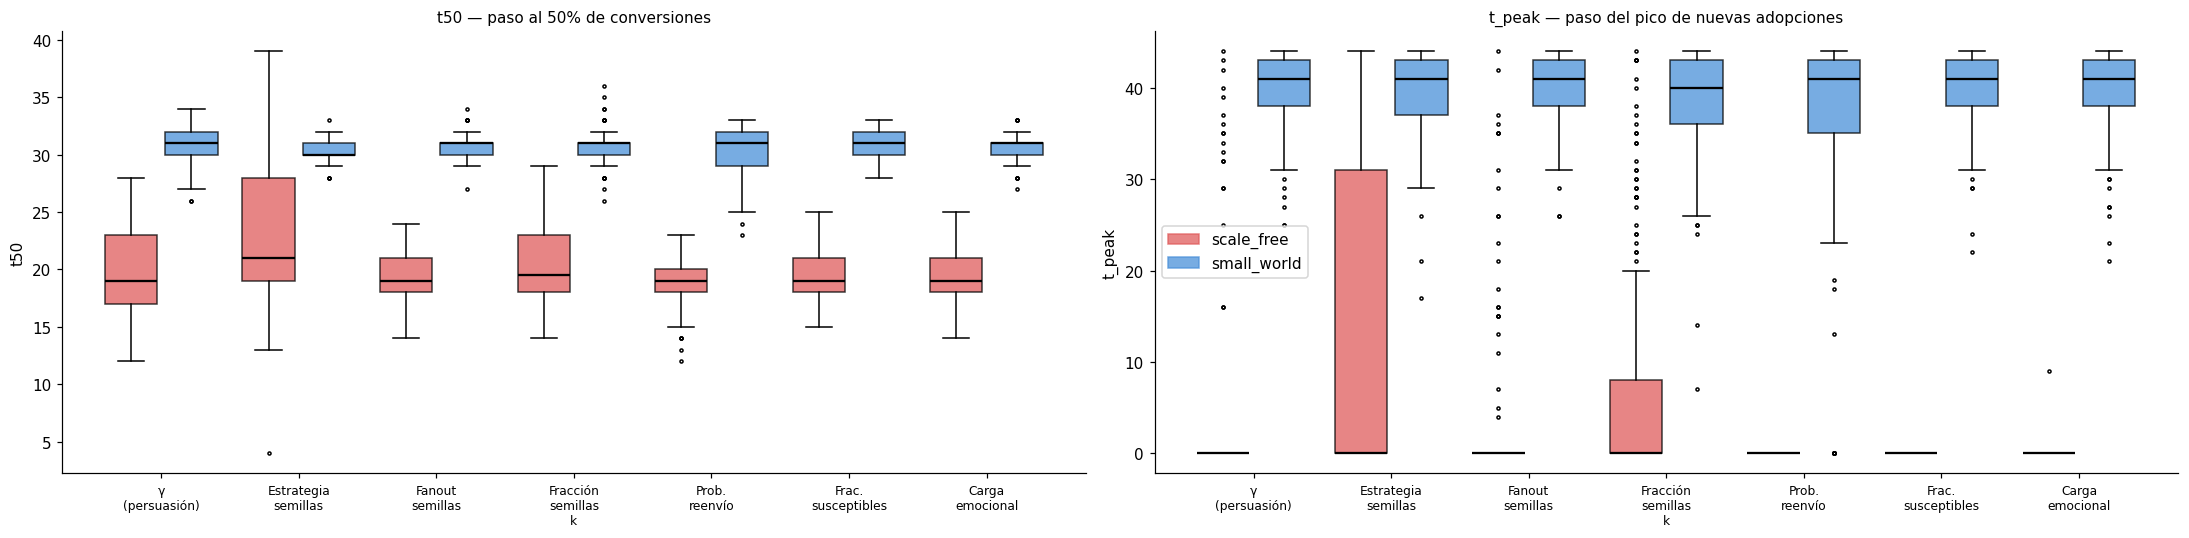

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

for ax, (metric, title) in zip(
    axes,
    [
        ("t50",    "t50 — paso al 50% de conversiones"),
        ("t_peak", "t_peak — paso del pico de nuevas adopciones"),
    ],
):
    data_sf: list[list[float]] = []
    data_sw: list[list[float]] = []
    xlabels: list[str] = []

    for factor in FACTORS_ORDERED:
        sub = df[(df["factor"] == factor)].dropna(subset=[metric])
        data_sf.append(sub[sub["topology"] == "scale_free"][metric].tolist())
        data_sw.append(sub[sub["topology"] == "small_world"][metric].tolist())
        xlabels.append(FACTOR_LABELS[factor].replace(" ", "\n"))

    x = np.arange(len(FACTORS_ORDERED))
    ax.boxplot(
        data_sf, positions=x - 0.22, widths=0.38, patch_artist=True,
        boxprops=dict(facecolor=COLORS["scale_free"], alpha=0.75),
        medianprops=dict(color="black", lw=1.5),
        whiskerprops=dict(lw=1), capprops=dict(lw=1),
        flierprops=dict(marker=".", ms=4),
    )
    ax.boxplot(
        data_sw, positions=x + 0.22, widths=0.38, patch_artist=True,
        boxprops=dict(facecolor=COLORS["small_world"], alpha=0.75),
        medianprops=dict(color="black", lw=1.5),
        whiskerprops=dict(lw=1), capprops=dict(lw=1),
        flierprops=dict(marker=".", ms=4),
    )
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, fontsize=8)
    ax.set_ylabel(metric)
    ax.set_title(title, fontsize=10)

handles = [mpatches.Patch(color=c, alpha=0.75, label=t) for t, c in COLORS.items()]
axes[1].legend(handles=handles)
plt.tight_layout()
fig.savefig(IMG_DIR / "sweep_t50_tpeak.png", dpi=200, bbox_inches="tight")
plt.show()

## 4.6 Heatmap resumen factor × nivel

Media y desviación típica de resiliencia por (factor, nivel). De un vistazo:
qué palancas importan (alta variación en media) y cuáles generan runs inestables
(alta std).

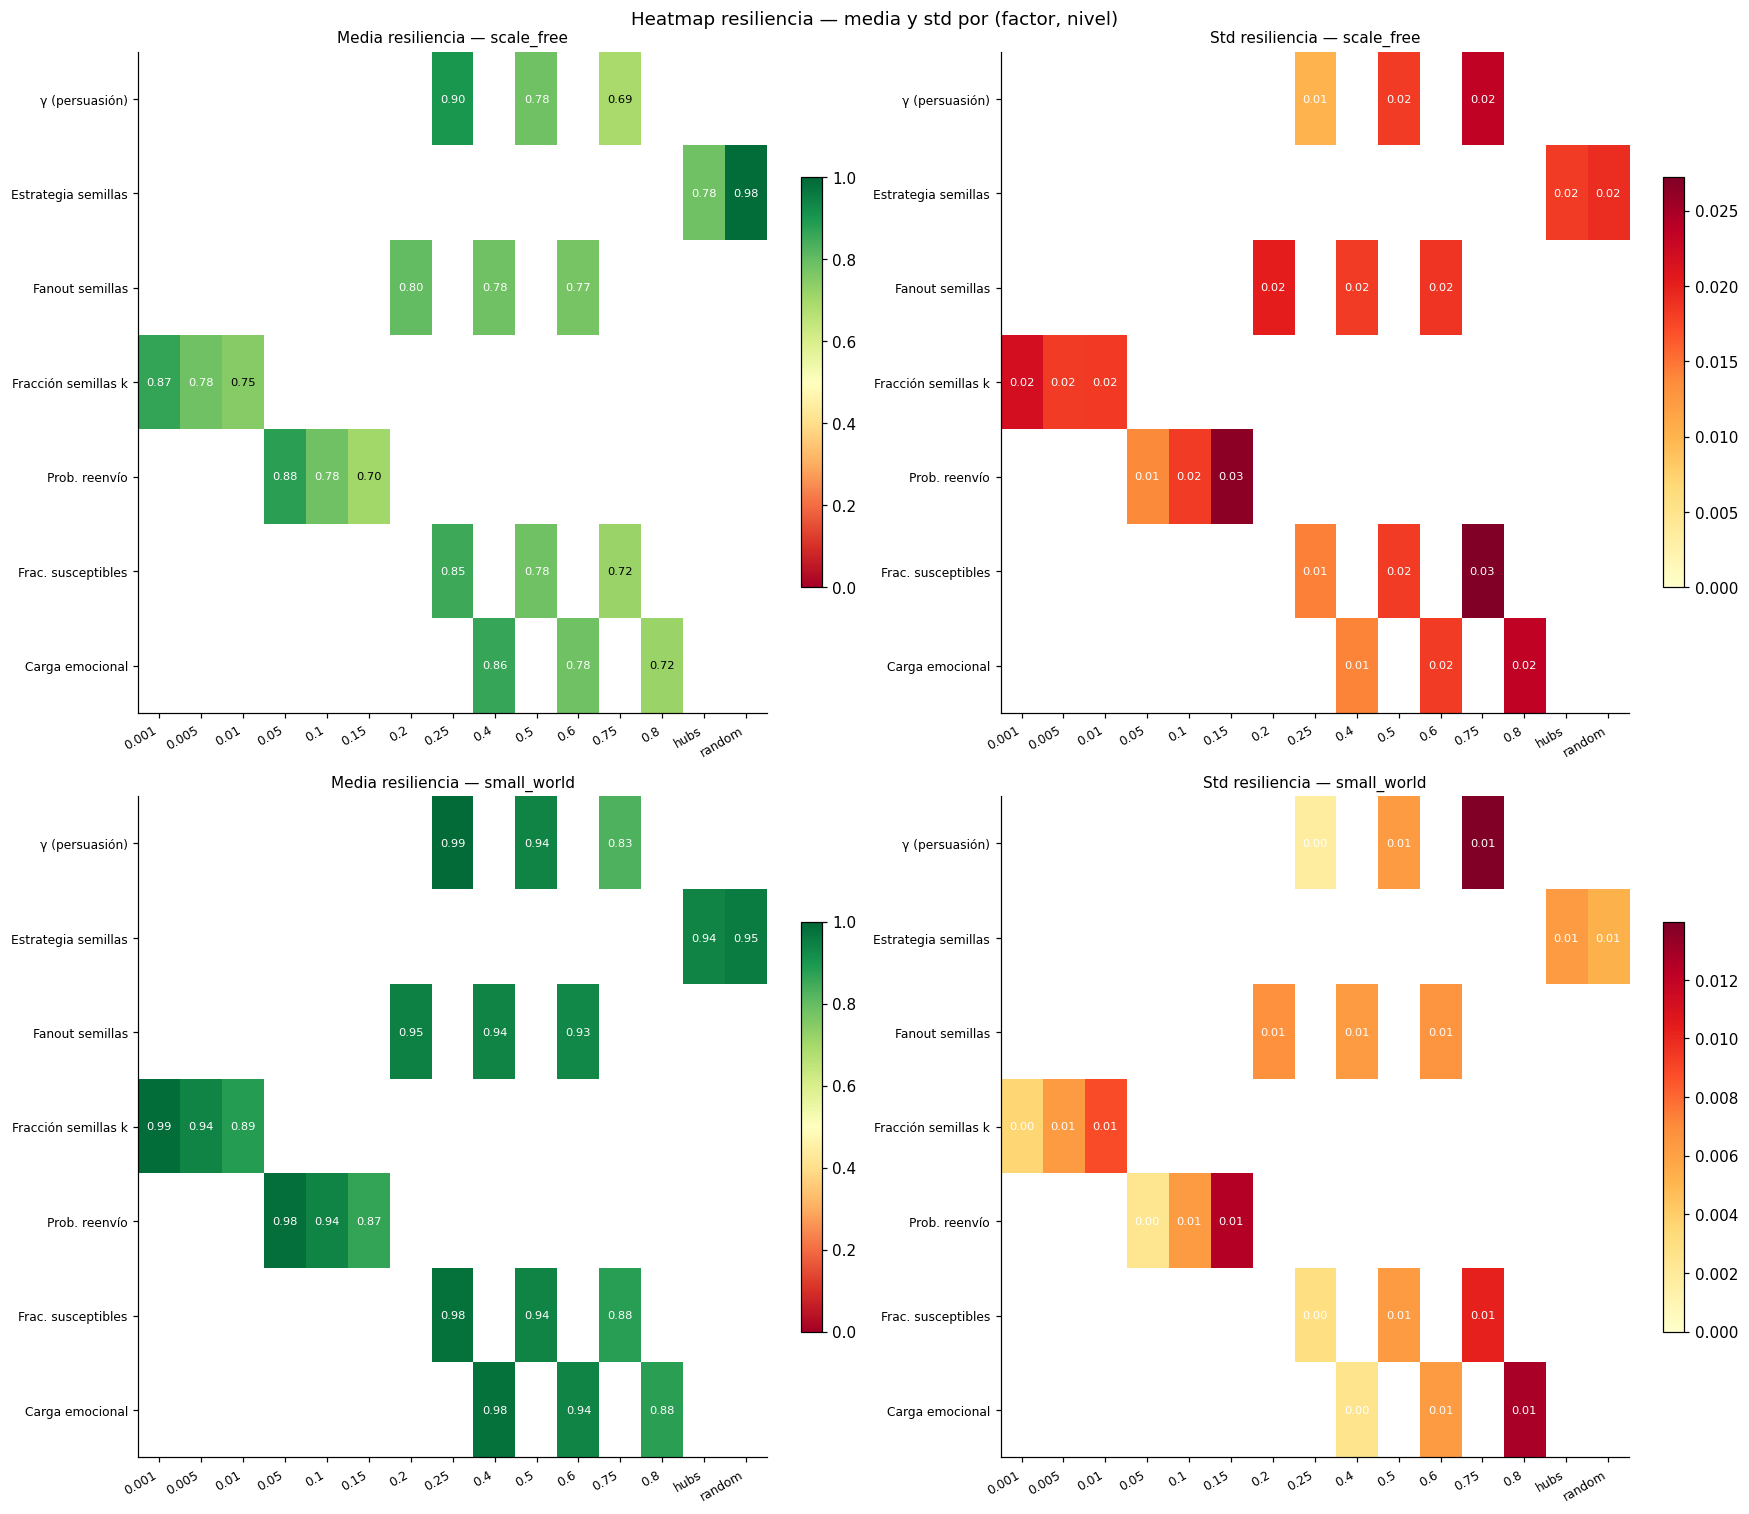

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for row_idx, topo in enumerate(COLORS.keys()):
    sub = df[df["topology"] == topo]
    agg = (
        sub.groupby(["factor", "valor_str"])["resiliencia"]
        .agg(["mean", "std"])
        .reset_index()
    )

    mean_piv = agg.pivot(index="factor", columns="valor_str", values="mean").reindex(FACTORS_ORDERED)
    std_piv  = agg.pivot(index="factor", columns="valor_str", values="std").reindex(FACTORS_ORDERED)

    for col_idx, (piv, cmap_name, subtitle) in enumerate([
        (mean_piv, "RdYlGn", f"Media resiliencia — {topo}"),
        (std_piv,  "YlOrRd", f"Std resiliencia — {topo}"),
    ]):
        ax = axes[row_idx][col_idx]
        vals = piv.values.astype(float)
        vmax = 1.0 if col_idx == 0 else None
        im = ax.imshow(vals, aspect="auto", cmap=cmap_name, vmin=0, vmax=vmax)

        ax.set_xticks(range(vals.shape[1]))
        ax.set_xticklabels(piv.columns, rotation=30, ha="right", fontsize=8)
        present_factors = [f for f in FACTORS_ORDERED if f in (piv.index.tolist())]
        ax.set_yticks(range(len(present_factors)))
        ax.set_yticklabels([FACTOR_LABELS[f] for f in present_factors], fontsize=8)
        ax.set_title(subtitle, fontsize=10)
        plt.colorbar(im, ax=ax, fraction=0.03)

        for ii in range(vals.shape[0]):
            for jj in range(vals.shape[1]):
                v = vals[ii, jj]
                if not np.isnan(v):
                    text_color = "black" if (col_idx == 0 and 0.25 < v < 0.75) else "white"
                    ax.text(jj, ii, f"{v:.2f}", ha="center", va="center",
                            fontsize=7.5, color=text_color)

fig.suptitle("Heatmap resiliencia — media y std por (factor, nivel)", fontsize=12)
plt.tight_layout()
fig.savefig(IMG_DIR / "sweep_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

## 4.7 Envolvente global de adopción y distribución de t50 — semilla hubs

Agrega los runs del barrido con estrategia de semilla **hubs** por topología
(excluye los runs `seed_strategy=random`).

- **Línea sólida**: media de creyentes acumulados.
- **Bandas de percentiles**: la tonalidad indica la densidad de curvas —
  más oscuro donde se concentra la mayoría de runs (IQR p25–p75),
  más claro en los extremos poco frecuentes (p5–p95).
  El rango completo (mín–máx) se muestra con línea discontinua fina.
- **t50**: histograma del paso al 50 % de conversiones con marcas de mín, media y máx.

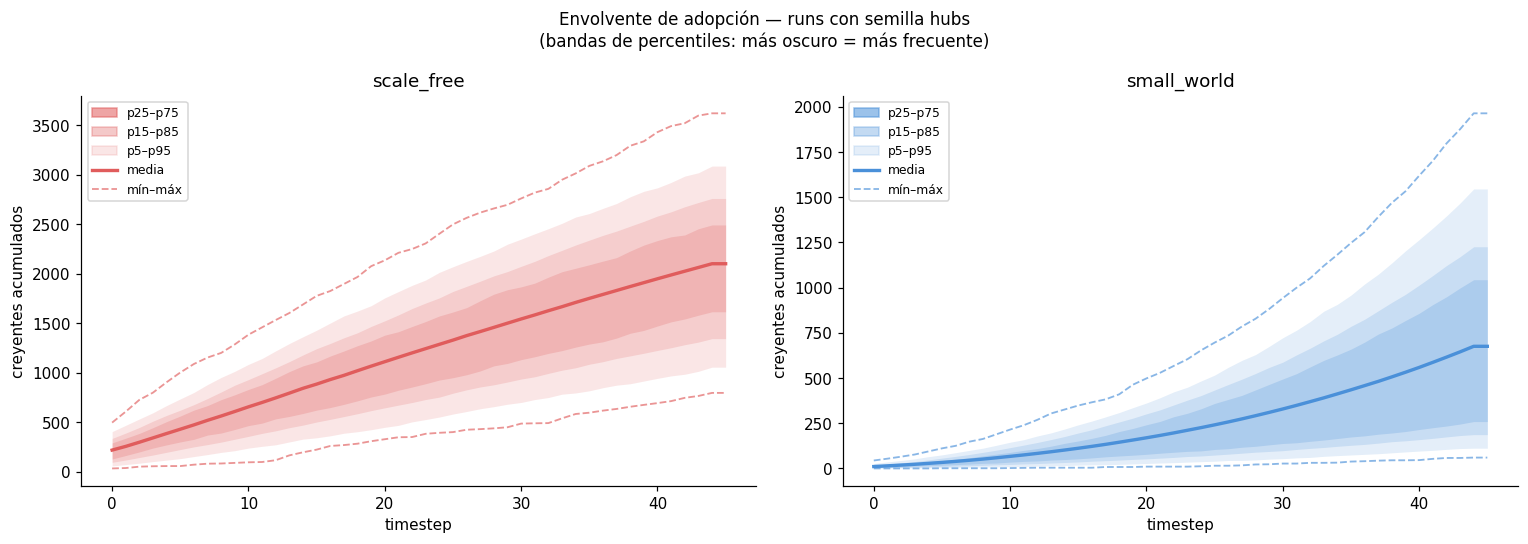

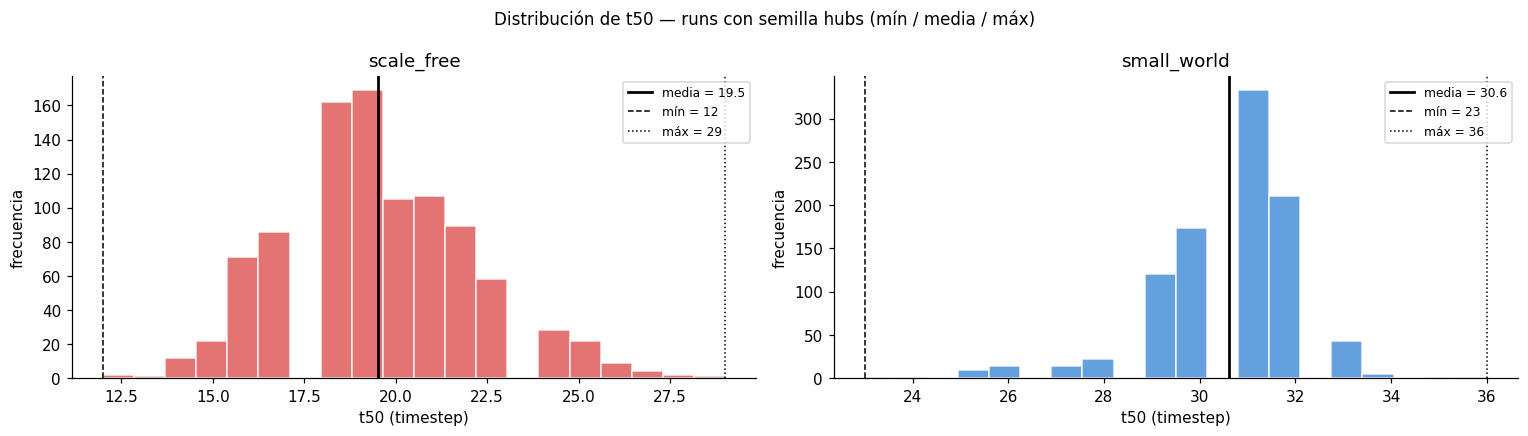

In [10]:
t_axis = np.arange(STEPS_TOTAL + 1)

# Excluir los runs con semilla aleatoria (solo conservar hubs y el resto de factores)
df_hubs = df[~((df["factor"] == "seed_strategy") & (df["valor_str"] == "random"))]

# Bandas de percentiles: (low_pct, high_pct, alpha_adicional)
# Se apilan de fuera hacia dentro → cada capa interna suma opacidad.
PCT_BANDS = [(5, 95, 0.15), (15, 85, 0.18), (25, 75, 0.22)]


def _load_all_cum_curves(topo: str) -> np.ndarray:
    """Carga todas las curvas de adopción acumulada del sweep para una topología."""
    curves = []
    for _, row in df_hubs[df_hubs["topology"] == topo].iterrows():
        path = (
            SWEEP_ROOT / topo / row["factor"]
            / f"{row['factor']}={row['valor_str']}" / f"seed={int(row['seed'])}"
            / "sim" / "simulation_adoptions.csv"
        )
        if not path.exists():
            continue
        adp = pd.read_csv(path)
        by_t = adp.groupby("timestep").size()
        cum = by_t.cumsum().reindex(range(STEPS_TOTAL + 1), method="ffill").fillna(0)
        curves.append(cum.to_numpy())
    return np.array(curves) if curves else np.zeros((1, STEPS_TOTAL + 1))


# — Curvas de adopción: media + bandas de percentiles ————————————————————
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (topo, color) in zip(axes, COLORS.items()):
    curves = _load_all_cum_curves(topo)
    mean_c = curves.mean(axis=0)
    min_c  = curves.min(axis=0)
    max_c  = curves.max(axis=0)

    # Bandas percentílicas (de exterior a interior, opacidad creciente)
    for lo, hi, alpha in PCT_BANDS:
        lo_c = np.percentile(curves, lo, axis=0)
        hi_c = np.percentile(curves, hi, axis=0)
        ax.fill_between(t_axis, lo_c, hi_c, color=color, alpha=alpha, linewidth=0)

    # Rango absoluto (mín–máx)
    ax.plot(t_axis, max_c, color=color, lw=1.2, ls="--", alpha=0.65)
    ax.plot(t_axis, min_c, color=color, lw=1.2, ls="--", alpha=0.65)

    ax.plot(t_axis, mean_c, color=color, lw=2.2, label="media")

    # Leyenda manual de bandas (alphas acumulados: 0.15 / 0.33 / 0.55)
    handles = [
        mpatches.Patch(color=color, alpha=0.55, label="p25–p75"),
        mpatches.Patch(color=color, alpha=0.33, label="p15–p85"),
        mpatches.Patch(color=color, alpha=0.15, label="p5–p95"),
        plt.Line2D([0], [0], color=color, lw=2.2,              label="media"),
        plt.Line2D([0], [0], color=color, lw=1.2, ls="--", alpha=0.65, label="mín–máx"),
    ]
    ax.legend(handles=handles, fontsize=8)
    ax.set_title(topo)
    ax.set_xlabel("timestep")
    ax.set_ylabel("creyentes acumulados")

fig.suptitle(
    "Envolvente de adopción — runs con semilla hubs\n"
    "(bandas de percentiles: más oscuro = más frecuente)",
    fontsize=11,
)
plt.tight_layout()
fig.savefig(IMG_DIR / "sweep_envolvente.png", dpi=200, bbox_inches="tight")
plt.show()

# — Distribución de t50: histograma + mín/media/máx ———————————————————
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (topo, color) in zip(axes, COLORS.items()):
    t50_vals = df_hubs[df_hubs["topology"] == topo]["t50"].dropna().to_numpy()
    t50_mean = t50_vals.mean()
    t50_min  = int(t50_vals.min())
    t50_max  = int(t50_vals.max())
    ax.hist(t50_vals, bins=20, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(t50_mean, color="black", lw=1.8, ls="-",  label=f"media = {t50_mean:.1f}")
    ax.axvline(t50_min,  color="black", lw=1.0, ls="--", label=f"mín = {t50_min}")
    ax.axvline(t50_max,  color="black", lw=1.0, ls=":",  label=f"máx = {t50_max}")
    ax.set_title(topo)
    ax.set_xlabel("t50 (timestep)")
    ax.set_ylabel("frecuencia")
    ax.legend(fontsize=8)
fig.suptitle(
    "Distribución de t50 — runs con semilla hubs (mín / media / máx)",
    fontsize=11,
)
plt.tight_layout()
plt.show()

## Drill-down: análisis por-nodo comparando las dos topologías

Carga los ficheros de una celda concreta del barrido y muestra en paralelo los
plots de `analisis_nodo_resistente.ipynb` para **scale\_free** (fila superior)
y **small\_world** (fila inferior) con los mismos parámetros de narrativa.

Edita `DRILL_*` para apuntar a cualquier celda de `sweep_summary.csv`.

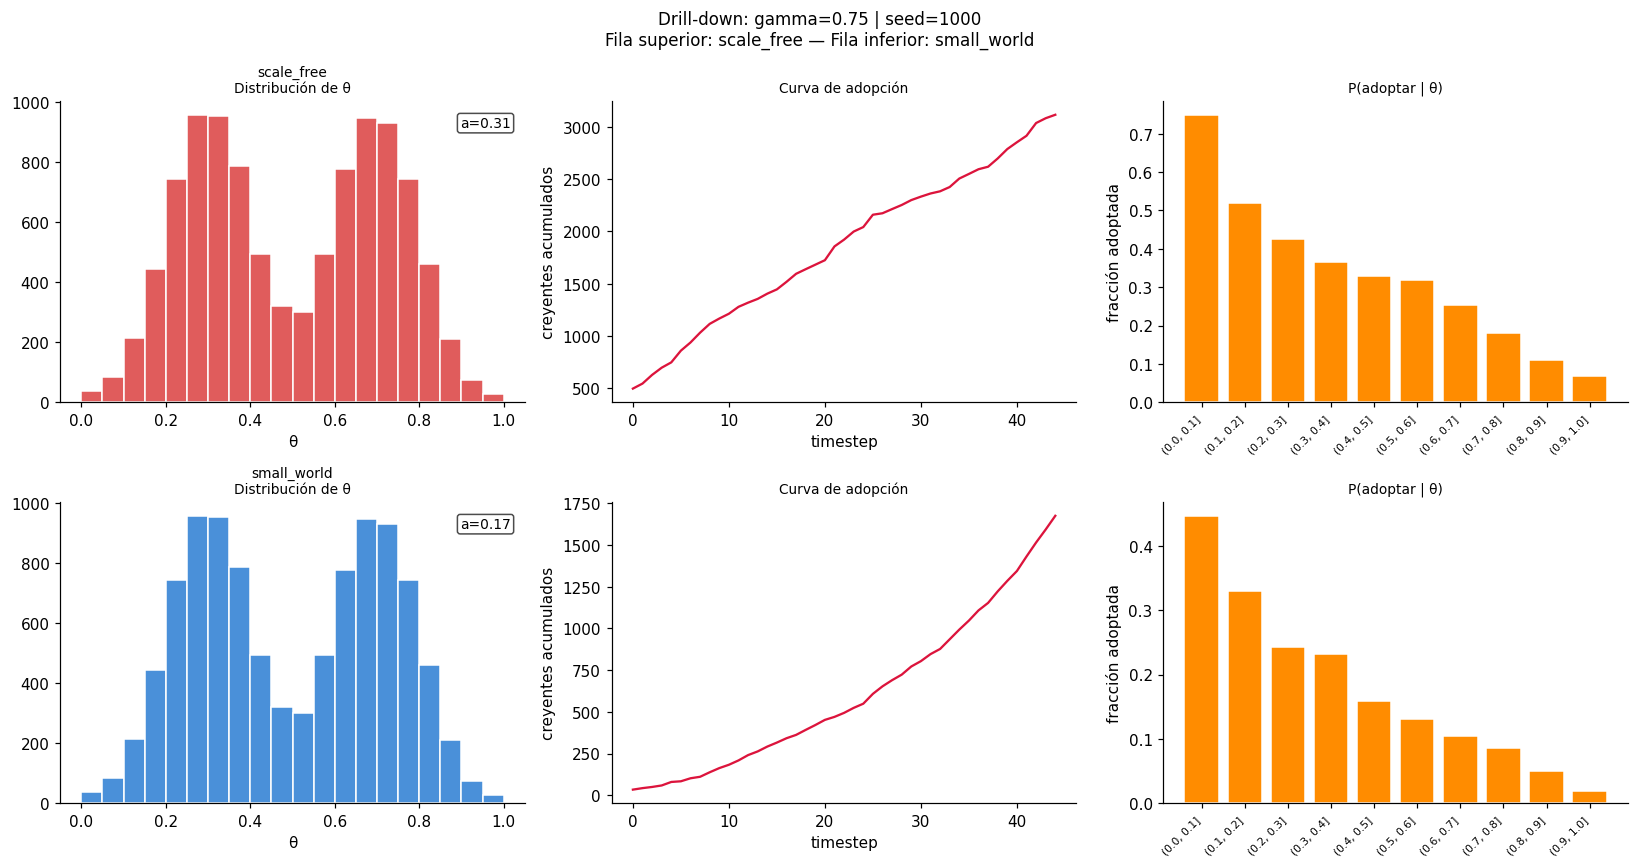

In [11]:
# --- Selecciona el run a inspeccionar --------------------------------------
DRILL_FACTOR = "gamma"
DRILL_VALOR  = "0.75"
DRILL_SEED   = 1000
BASENAME     = "simulation"
NARRATIVE_VERACITY_THRESHOLD = 0.30
DRILL_TOPOS  = ["scale_free", "small_world"]
# --------------------------------------------------------------------------


def _load_drill(topo: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame] | None:
    sim_dir = (
        SWEEP_ROOT / topo / DRILL_FACTOR
        / f"{DRILL_FACTOR}={DRILL_VALOR}" / f"seed={DRILL_SEED}" / "sim"
    )
    if not sim_dir.exists():
        print(f"Run no encontrado: {sim_dir}")
        return None
    states = pd.read_csv(sim_dir / f"{BASENAME}_agent_states.csv")
    for col in ["adopted", "is_seed"]:
        states[col] = states[col].astype(str).str.lower().map({"true": True, "false": False})
    adoptions_p = sim_dir / f"{BASENAME}_adoptions.csv"
    adoptions = pd.read_csv(adoptions_p) if adoptions_p.exists() else pd.DataFrame()
    msg_p = sim_dir / f"{BASENAME}.csv"
    messages = pd.read_csv(msg_p) if msg_p.exists() else pd.DataFrame()
    return states, adoptions, messages


fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for row, topo in enumerate(DRILL_TOPOS):
    result = _load_drill(topo)
    if result is None:
        continue
    states, adoptions, messages = result

    N       = len(states)
    n_seeds = int(states["is_seed"].sum())
    n_conv  = int(((states["adopted"]) & (~states["is_seed"])).sum())
    denom   = N - n_seeds
    ar      = n_conv / denom if denom else float("nan")

    # --- col 0: distribución θ ---
    ax = axes[row, 0]
    ax.hist(states["theta"], bins=20, color=list(COLORS.values())[row], edgecolor="white")
    ax.set_title(f"{topo}\nDistribución de θ", fontsize=9)
    ax.set_xlabel("θ")
    ax.text(0.97, 0.95, f"a={ar:.2f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

    # --- col 1: curva de adopción ---
    ax = axes[row, 1]
    if len(adoptions) > 0:
        by_t = adoptions.sort_values("timestep").groupby("timestep").size()
        t_max = int(messages["timestep"].max()) if len(messages) else int(by_t.index.max())
        cum = by_t.cumsum().reindex(range(t_max + 1), method="ffill").fillna(0)
        ax.plot(cum.index, cum.values, c="crimson", lw=1.5)
    ax.set_title("Curva de adopción", fontsize=9)
    ax.set_xlabel("timestep")
    ax.set_ylabel("creyentes acumulados")

    # --- col 2: dosis-respuesta P(adoptar | θ) ---
    ax = axes[row, 2]
    non_seed = states[~states["is_seed"]].copy()
    non_seed["theta_bin"] = pd.cut(non_seed["theta"], bins=np.linspace(0, 1, 11))
    resp = non_seed.groupby("theta_bin", observed=True)["adopted"].mean()
    ax.bar(range(len(resp)), resp.values, color="darkorange", edgecolor="white")
    ax.set_xticks(range(len(resp)))
    ax.set_xticklabels([str(b) for b in resp.index], rotation=45, ha="right", fontsize=7)
    ax.set_title("P(adoptar | θ)", fontsize=9)
    ax.set_ylabel("fracción adoptada")

fig.suptitle(
    f"Drill-down: {DRILL_FACTOR}={DRILL_VALOR} | seed={DRILL_SEED}\n"
    "Fila superior: scale_free — Fila inferior: small_world",
    fontsize=11,
)
plt.tight_layout()
plt.show()